# Iris Category Classification

框架：Pytorch

## 实验介绍
- Iris分类是机器学习中的经典任务，旨在根据鸢尾花的特征（如花萼长度、花萼宽度、花瓣长度、花瓣宽度）将其分类为三种不同的品种：Setosa、Versicolor和Virginica。
- 本实验使用Pytorch框架，构建一个简单的神经网络模型来实现Iris分类任务。

## 导入所需的库和数据
使用 `sklearn` 库中的 `load_iris` 函数加载Iris数据集。

In [1]:
# 导入必要的库
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 加载Iris数据集
iris = load_iris()
X = iris.data  # 特征数据
y = iris.target.reshape(-1, 1)  # 标签数据

Using device: cuda


## 数据预处理
- 将标签进行One-Hot编码，以适应神经网络的输出格式。
- 将数据集划分为训练集和测试集。

One-Hot编码介绍

One-Hot编码是一种将分类变量转换为二进制向量的技术。对于每个类别，创建一个新的二进制特征，表示该类别是否存在。这样可以避免模型对类别之间的顺序产生误解。

例如，对于三个类别A、B、C，One-Hot编码如下：
- A: \[1, 0, 0\]
- B: \[0, 1, 0\]
- C: \[0, 0, 1\]

这样可以确保每个类别被独立表示，适用于分类任务中的模型训练。在本实验中，我们将Iris数据集的标签进行One-Hot编码，以便神经网络能够正确地处理多类别分类问题。

In [2]:
# One-Hot编码标签
encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y)
# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)
# 转换为PyTorch张量
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.FloatTensor(y_train).to(device)
X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.FloatTensor(y_test).to(device)

## 定义神经网络模型
构建一个简单的前馈神经网络模型，包括输入层、隐藏层和输出层。
- 输入层：4个神经元（对应4个特征），无激活函数
- 隐藏层：使用ReLU激活函数。设计了2个隐藏层，每层10个神经元
- 输出层：3个神经元，使用Softmax激活函数（对应3个类别）
    - 为了避免数值稳定性问题，输出层不直接使用Softmax函数，而是在计算损失时使用`nn.CrossEntropyLoss`，该函数内部会处理Softmax计算。

In [3]:
# 定义神经网络模型
class IrisClassificationModel(nn.Module):
    def __init__(self):
        super(IrisClassificationModel, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(4, 10),
            nn.ReLU(),
            nn.Linear(10, 10),
            nn.ReLU(),
            nn.Linear(10, 3)  # 输出层，3个神经元
        )
    def forward(self, x):
        x = self.network(x)
        return x

## 训练模型
使用交叉熵损失函数和Adam优化器进行训练。

In [4]:
# 初始化模型、损失函数和优化器
model = IrisClassificationModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
# 训练模型
num_epochs = 100
loss_history = []
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    # 前向传播
    outputs = model(X_train_tensor)
    # 计算损失
    loss = criterion(outputs, torch.max(y_train_tensor, 1)[1])
    # 反向传播和优化
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [10/100], Loss: 0.9646
Epoch [20/100], Loss: 0.6713
Epoch [30/100], Loss: 0.4558
Epoch [40/100], Loss: 0.3495
Epoch [50/100], Loss: 0.2372
Epoch [60/100], Loss: 0.1369
Epoch [70/100], Loss: 0.0867
Epoch [80/100], Loss: 0.0686
Epoch [90/100], Loss: 0.0617
Epoch [100/100], Loss: 0.0584


## 评估模型
计算模型在测试集上的准确率。

In [5]:
# 评估模型
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    _, predicted = torch.max(test_outputs.data, 1)
    _, labels = torch.max(y_test_tensor.data, 1)
    accuracy = (predicted == labels).sum().item() / labels.size(0)
    print(f'Accuracy on test set: {accuracy * 100:.2f}%')

Accuracy on test set: 96.67%


## 可视化训练过程
绘制训练损失随迭代次数变化的曲线。

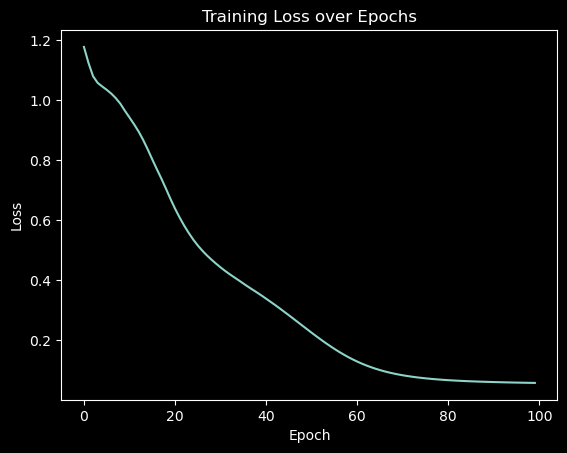

In [6]:
# 可视化训练损失
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.show()

## 总结
- 本实验使用Pytorch框架构建了一个简单的神经网络模型，实现了Iris分类任务。
- 通过训练和评估，模型在测试集上达到了较高的准确率，展示了神经网络在分类任务中的有效性。
- 通过可视化训练损失，观察到模型的收敛过程，为后续的模型改进提供了参考。